# Week 4: Noise Sensitivity Analysis and Threshold Tuning

**Day 1 - Build a genuine held-out test set + clean baseline**

Goal for today: create a test set the model has truly never seen, train an evaluation model on the remaining 80% using the same approach and hyperparameters that won in Week 3, and record clean (no-noise) performance as today's reference line.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

import joblib

np.random.seed(42)

In [2]:
DATA_PATH = "ai4i_fused_week2.csv"  # your Week 2 output

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10000, 22)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,OSF,RNF,timestamp,ambient_temp_C,load_density_pct,ambient_temp_K,temp_differential_K,load_adjusted_torque,wear_per_load,Type_enc
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,1/1/2024 0:00,18.913477,38.362480,292.063477,6.036523,108.732986,0.000000,2
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,1/1/2024 0:10,18.913477,38.362480,292.063477,6.136523,117.624702,1.150874,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,1/1/2024 0:20,18.913477,38.362480,292.063477,6.036523,125.500222,1.918124,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,1/1/2024 0:30,18.913477,38.362480,292.063477,6.136523,100.349368,2.685374,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,1/1/2024 0:40,17.610902,37.186934,290.760902,7.439098,104.747869,3.346824,1


## Step 1 - Recreate the Week 3 feature set

Same leakage-aware feature list as Week 3 - the five failure-mode flags directly define `Machine failure`, so they stay excluded.

In [3]:
target = "Machine failure"
leak_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
drop_cols = ["UDI", "Product ID", "Type", "timestamp", target] + leak_cols

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols]
y = df[target]

print(f"Using {len(feature_cols)} features")

Using 12 features


## Step 2 - The winning approach and best hyperparameters from Week 3

In [4]:
# Set this to match whatever won in YOUR Week 3 three-way comparison
WINNING_APPROACH = "class_weight"  # or "smote"

tuning_df = pd.read_csv("week3_hyperparameter_tuning_results.csv")
best_row = tuning_df.loc[tuning_df["f1"].idxmax()]
best_params = {
    "num_leaves": int(best_row["num_leaves"]),
    "learning_rate": float(best_row["learning_rate"]),
    "n_estimators": int(best_row["n_estimators"]),
}
print("Winning approach:", WINNING_APPROACH)
print("Best hyperparameters:", best_params)

Winning approach: class_weight
Best hyperparameters: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 200}


In [5]:
def build_model(params, approach, y_train=None):
    if approach == "smote":
        return ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("clf", lgb.LGBMClassifier(random_state=42, verbose=-1, **params)),
        ])
    else:
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        spw = neg / pos
        return lgb.LGBMClassifier(random_state=42, verbose=-1, scale_pos_weight=spw, **params)

## Step 3 - A fresh, genuinely held-out 80/20 split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train)} rows ({y_train.mean()*100:.3f}% failures)")
print(f"Test:  {len(X_test)} rows ({y_test.mean()*100:.3f}% failures)")

Train: 8000 rows (3.388% failures)
Test:  2000 rows (3.400% failures)


## Step 4 - Fit the evaluation model, get the clean baseline

This exact fitted model is what every noise level in Day 2 will be tested against - nothing about the model changes this week, only the input data.

In [7]:
X_train_cleaned = X_train.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_').replace(' ', '_'))
X_test_cleaned = X_test.rename(columns=lambda x: x.replace('[', '_').replace(']', '_').replace('<', '_').replace(' ', '_'))

eval_model = build_model(best_params, WINNING_APPROACH, y_train)
eval_model.fit(X_train_cleaned, y_train)

proba_clean = eval_model.predict_proba(X_test_cleaned)[:, 1]
pred_clean = eval_model.predict(X_test_cleaned)

clean_baseline = {
    "noise_level": 0.0,
    "recall": recall_score(y_test, pred_clean),
    "precision": precision_score(y_test, pred_clean, zero_division=0),
    "f1": f1_score(y_test, pred_clean),
    "roc_auc": roc_auc_score(y_test, proba_clean),
    "pr_auc": average_precision_score(y_test, proba_clean),
}

print("Clean (no-noise) baseline on held-out test set:")
for k, v in clean_baseline.items():
     print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Clean (no-noise) baseline on held-out test set:
  noise_level: 0.0000
  recall: 0.7647
  precision: 0.8387
  f1: 0.8000
  roc_auc: 0.9696
  pr_auc: 0.8423


## Step 5 - Save everything Day 2 needs

In [8]:
joblib.dump(eval_model, "week4_eval_model.joblib")
X_test.to_csv("week4_X_test.csv", index=False)
y_test.to_csv("week4_y_test.csv", index=False)
pd.DataFrame([clean_baseline]).to_csv("week4_clean_baseline.csv", index=False)

print("Saved week4_eval_model.joblib, week4_X_test.csv, week4_y_test.csv, week4_clean_baseline.csv")

Saved week4_eval_model.joblib, week4_X_test.csv, week4_y_test.csv, week4_clean_baseline.csv


## Day 2 - Inject synthetic noise, measure the damage

Goal: empirically characterize how much the model's performance degrades as sensor readings get noisier, instead of just claiming "it's robust." Noise is added only to the held-out test set (`X_test` from Day 1) - the model itself never changes, so any difference in the numbers below is caused purely by the noisier input.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score
)

np.random.seed(42)

eval_model = joblib.load("week4_eval_model.joblib")
X_test = pd.read_csv("week4_X_test.csv")
y_test = pd.read_csv("week4_y_test.csv").iloc[:, 0]

print(X_test.shape, y_test.shape)

(2000, 12) (2000,)


### Step 1 - Decide which columns actually get noise

`Type_enc` is a categorical code (0, 1, 2 for product quality variant), not a continuous sensor reading - adding Gaussian noise to it would just produce meaningless fractional category values. Noise only makes sense on the genuinely continuous sensor and context features.

In [10]:
noise_cols = [c for c in X_test.columns if c != "Type_enc"]
print(f"Adding noise to {len(noise_cols)} continuous features:")
print(noise_cols)

Adding noise to 11 continuous features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'ambient_temp_C', 'load_density_pct', 'ambient_temp_K', 'temp_differential_K', 'load_adjusted_torque', 'wear_per_load']


### Step 2 - Inject noise scaled to each feature's own spread

A fixed noise amount (say, +/-5 units) would be huge for a feature that normally varies by 2 and trivial for one that varies by 200. Scaling the noise to a percentage of each feature's own standard deviation keeps the disturbance comparable across very different sensors.

In [11]:
def add_gaussian_noise(X, cols, noise_level, random_state=None):
    rng = np.random.default_rng(random_state)
    X_noisy = X.copy()
    for col in cols:
        std = X[col].std()
        noise = rng.normal(0, noise_level * std, size=len(X))
        X_noisy[col] = X_noisy[col] + noise
    return X_noisy

### Step 3 - Evaluate the same fixed model at each noise level

In [12]:
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
results = []

for level in noise_levels:
    X_eval = X_test if level == 0.0 else add_gaussian_noise(X_test, noise_cols, level, random_state=42)

    proba = eval_model.predict_proba(X_eval)[:, 1]
    pred = eval_model.predict(X_eval)

    results.append({
        "noise_level": level,
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    })

noise_sensitivity = pd.DataFrame(results)
noise_sensitivity.round(4)

,noise_level,recall,precision,f1,roc_auc,pr_auc
0,0.00,0.7647,0.8387,0.8000,0.9696,0.8423
1,0.05,0.7206,0.8033,0.7597,0.9687,0.7680
2,0.10,0.7353,0.7143,0.7246,0.9662,0.7416
3,0.20,0.6324,0.5309,0.5772,0.9411,0.5669
4,0.30,0.5294,0.4235,0.4706,0.9173,0.4480


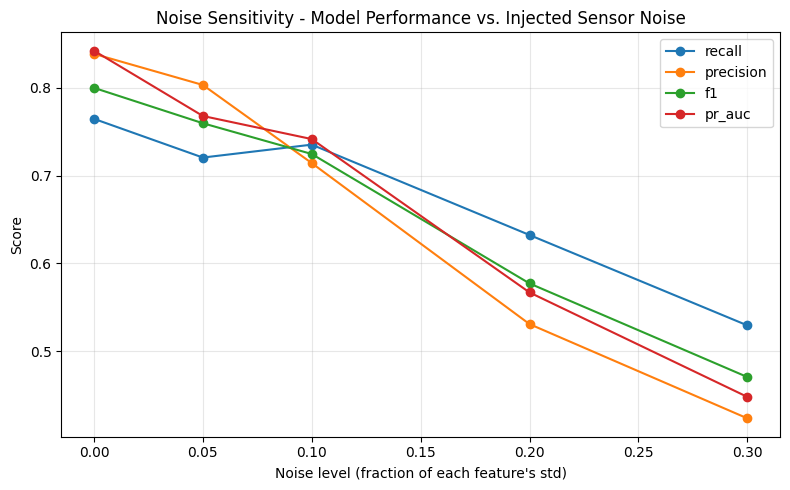

In [13]:
plt.figure(figsize=(8, 5))
for metric in ["recall", "precision", "f1", "pr_auc"]:
    plt.plot(noise_sensitivity["noise_level"], noise_sensitivity[metric], marker="o", label=metric)
plt.xlabel("Noise level (fraction of each feature's std)")
plt.ylabel("Score")
plt.title("Noise Sensitivity - Model Performance vs. Injected Sensor Noise")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("week4_noise_sensitivity.png", dpi=150)
plt.show()

In [14]:
noise_sensitivity.to_csv("week4_noise_sensitivity.csv", index=False)
print("Saved week4_noise_sensitivity.csv and week4_noise_sensitivity.png")

Saved week4_noise_sensitivity.csv and week4_noise_sensitivity.png


### Reading the curve

- **Flat lines** across noise levels mean the model's decisions barely depend on small fluctuations in the raw sensor values - a genuinely robust signal
- **A steep early drop** (performance falls a lot even at 5-10% noise) means the model is leaning on fine-grained precision in the sensor readings that real-world sensor drift would wipe out
- **Recall and precision dropping at different rates** matters for Day 4 - if recall falls faster than precision under noise, your chosen threshold may need to shift to compensate

One honest caveat worth a line in your report: this uses independent Gaussian noise per feature, which is a simplification. Real sensor degradation is often correlated across features (e.g., a failing thermocouple drifts steadily rather than jittering randomly) - this experiment measures a reasonable first-order robustness signal, not a worst-case guarantee.